# Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from tabulate import tabulate
import joblib


In [2]:
import logging
import os

log_path = r'/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/logs/EDA.log'

os.makedirs(os.path.dirname(log_path), exist_ok=True)

logging.basicConfig(
    filename=log_path,
    filemode='a',
    level=logging.INFO,
    format="%(asctime)s-%(levelname)s-%(message)s"
)

logging.info("EDA boshlandi")


In [3]:
try:
    df = pd.read_csv("/Users/sanjarbekkakhramonov/Desktop/Python course/5-oy/Project/data/raw/FR_raw.csv")
    logging.info(f"✅ Dataset yuklandi: {df.shape}")


except Exception as e:
    logging.exception("🔥 Dataset yuklashda kutilmagan xato!")
    raise




df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5320 entries, 0 to 5319
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   season        5320 non-null   object
 1   home_team     5320 non-null   object
 2   away_team     5320 non-null   object
 3   home_goals    5320 non-null   int64 
 4   away_goals    5320 non-null   int64 
 5   target        5320 non-null   int64 
 6   season_start  5320 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 291.1+ KB


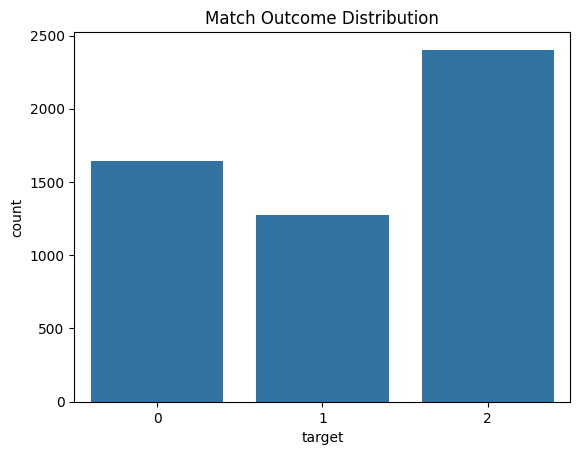

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="target")
plt.title("Match Outcome Distribution")
plt.show()

Bu yerda target classimiz imblanced ekan va uyda o'ynashni ustunligi ko'pro

In [9]:
home_stats = df.groupby("home_team")["home_goals"].mean().sort_values(ascending=False).head(10)
home_stats

home_team
Manchester City      2.661654
Liverpool            2.180451
Arsenal              2.097744
Chelsea              1.947368
Manchester United    1.943609
Tottenham Hotspur    1.875940
Blackpool            1.578947
Leicester City       1.573099
Newcastle United     1.526316
Everton              1.522556
Name: home_goals, dtype: float64

Uyda eng ko'p Mcity ustunlikka ega ekan

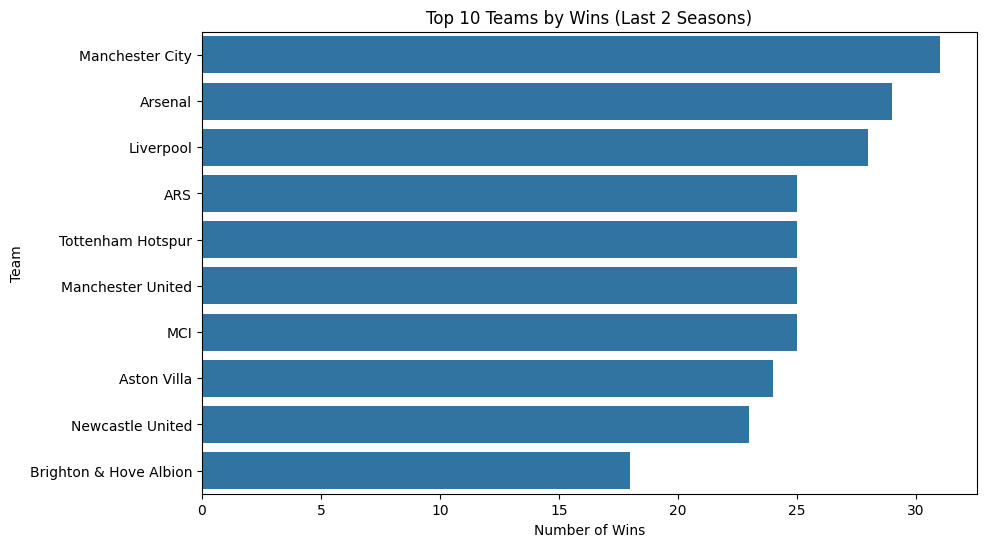

In [15]:
last_two = df[df["season_start"] >= df["season_start"].max() - 1].copy()
last_two["season_start"].unique()

# Home wins
home_wins = last_two[last_two["target"] == 2]["home_team"].value_counts()

# Away wins
away_wins = last_two[last_two["target"] == 0]["away_team"].value_counts()

# Umumiy wins
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)

total_wins.head(10)

import matplotlib.pyplot as plt
import seaborn as sns

top10 = total_wins.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 Teams by Wins (Last 2 Seasons)")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.show()

Bu graph shuni ko'rsatadiku oxirgi ikki mavsumda City va Arsenal uy uchrashuvlarida ko'p g'alaba qozongan